In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

ruta = '/content/drive/MyDrive/diabetes.csv'
df = pd.read_csv(ruta)

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.shape

(768, 9)

In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.duplicated().sum()

np.int64(0)

Reviso los valores faltantes

In [10]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
  print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


Reemplazo ceros por NaN

In [11]:
for col in cols:
  df[col] = df[col].replace(0, np.nan)

Imputar con mediana.
Se utilizó la mediana porque es menos sensible a valores extremos que la media

In [12]:
for col in cols:
  df[col] = df[col].fillna(df[col].median())

In [13]:
df[cols].isnull().sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.to_csv("diabetes_limpio.csv", index=False)

HISTOGRAMA DE NIVELES DE GLUCOSA

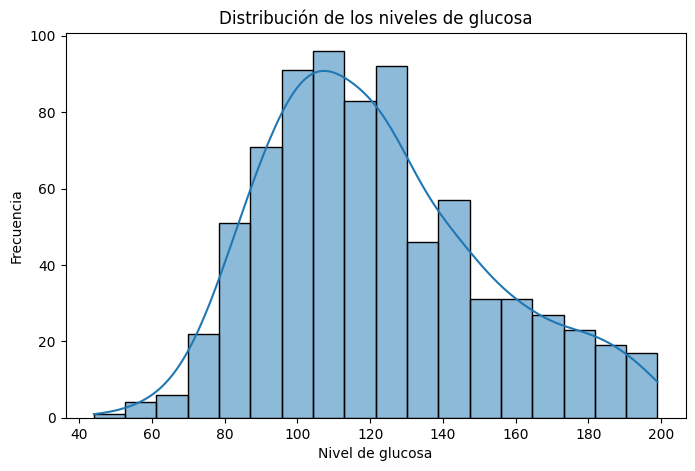

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["Glucose"], kde=True)

plt.title("Distribución de los niveles de glucosa")
plt.xlabel("Nivel de glucosa")
plt.ylabel("Frecuencia")

plt.show()

La mayoría de pacientes presenta niveles de glucosa entre 100 y 140 mg/dL

GRÁFICAS DE BARRAS DE PACIENTES CON Y SIN DIABETES

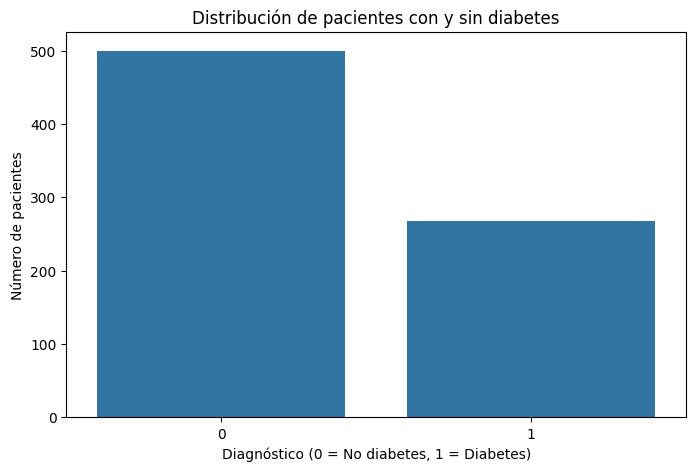

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x="Outcome", data=df)

plt.title("Distribución de pacientes con y sin diabetes")
plt.xlabel("Diagnóstico (0 = No diabetes, 1 = Diabetes)")
plt.ylabel("Número de pacientes")

plt.savefig("barras_outcome.png", bbox_inches="tight")

plt.show()

Hay mayor cantidad de pacientes sin diagnóstico de diabetes

BOXPLOT

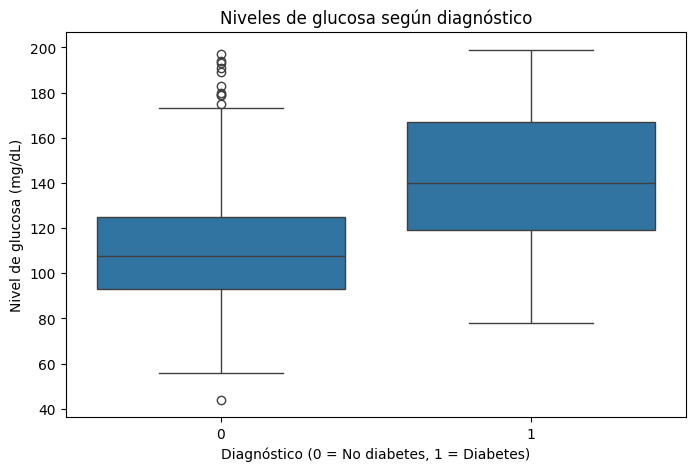

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="Glucose", data=df)

plt.title("Niveles de glucosa según diagnóstico")
plt.xlabel("Diagnóstico (0 = No diabetes, 1 = Diabetes)")
plt.ylabel("Nivel de glucosa (mg/dL)")

plt.savefig("boxplot_glucose.png", bbox_inches="tight")

plt.show()

Los pacientes con diabetes presentan niveles de glucosa más elevados

GRÁFICO DE DISPERSIÓN ENTRE EDAD Y GLUCOSA





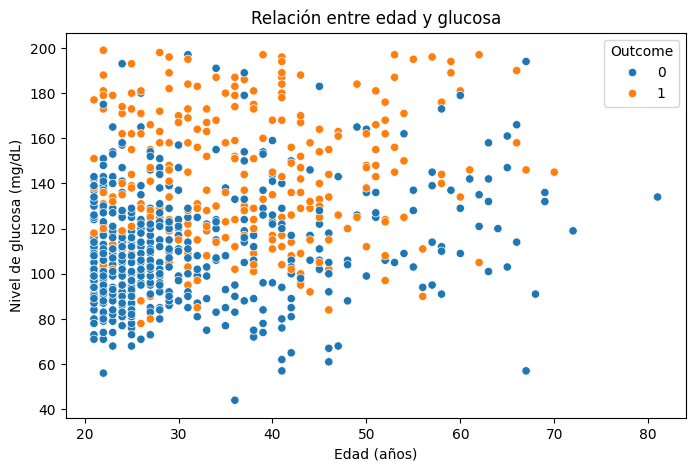

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Glucose",
    hue="Outcome",
    data=df
)

plt.title("Relación entre edad y glucosa")
plt.xlabel("Edad (años)")
plt.ylabel("Nivel de glucosa (mg/dL)")

plt.savefig("scatter_age_glucose.png", bbox_inches="tight")

plt.show()

Se observa una tendencia a mayores niveles de glucosa en pacientes diagnosticados.

MAPA DE CALOR

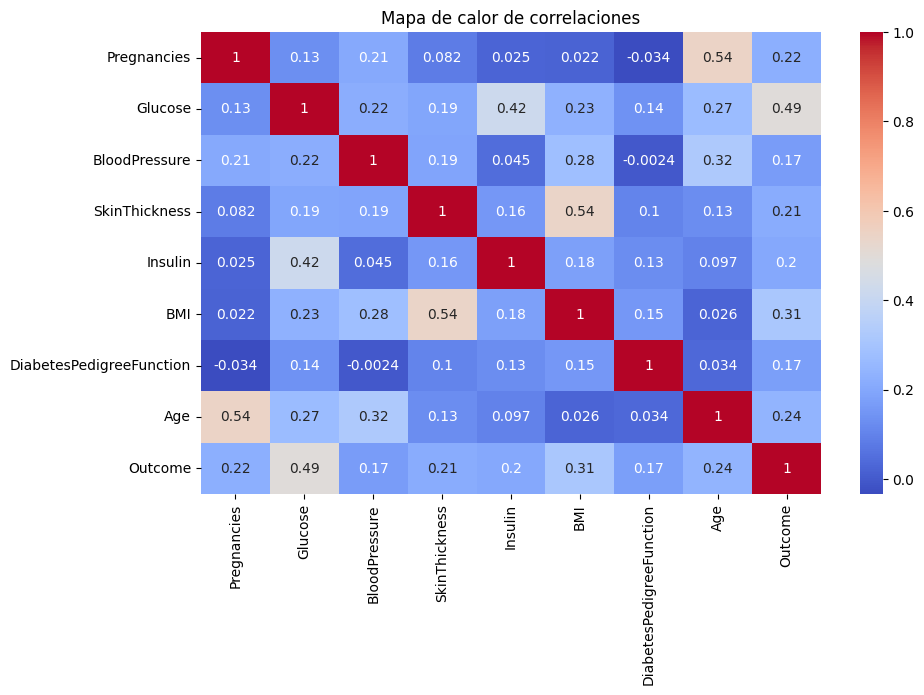

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Mapa de calor de correlaciones")

plt.savefig("heatmap_correlacion.png", bbox_inches="tight")

plt.show()

La glucosa presenta una de las correlaciones más altas con el diagnóstico de diabetes

In [23]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [32]:
corr_outcome = df.corr()["Outcome"].sort_values(ascending=False)
print(corr_outcome)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64
